In [ ]:
# Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

# Install evaluation dependency
!pip install -q torch-fidelity

import os
import math
import random
from time import time, perf_counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image

import matplotlib.pyplot as plt
from torch_fidelity import calculate_metrics


# -----------------------
# Global config & paths
# -----------------------
EXPERIMENT_NAME = "ECE285b_CIFAR10"
BASE_DIR = "/content"
PROJECT_DIR = os.path.join(BASE_DIR, EXPERIMENT_NAME)

# Where to store artifacts on Google Drive
DRIVE_ROOT = "/content/drive/MyDrive"
DRIVE_PROJECT_DIR = os.path.join(DRIVE_ROOT, EXPERIMENT_NAME)

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)

# Sub-dirs under project
DATA_DIR = os.path.join(PROJECT_DIR, "data")
TEACHER_CKPT_DIR = os.path.join(PROJECT_DIR, "teacher_ckpt")
CONSIST_CKPT_DIR = os.path.join(PROJECT_DIR, "consistency_ckpt")
FLOW_CKPT_DIR = os.path.join(PROJECT_DIR, "flow_ckpt")
SAMPLES_DIR = os.path.join(PROJECT_DIR, "samples")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")

for d in [DATA_DIR, TEACHER_CKPT_DIR, CONSIST_CKPT_DIR, FLOW_CKPT_DIR, SAMPLES_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# Training epochs for all models
EPOCHS_TEACHER = 100
EPOCHS_CONSIST = 100
EPOCHS_FLOW = 100

# Evaluation config
N_EVAL_SAMPLES = 10000  # number of samples to generate for FID/IS
# N_EVAL_SAMPLES = 100 # trial
EVAL_BATCH_SIZE = 100
FID_REF = "cifar10-train"  # reference stats in torch-fidelity

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Mounted at /content/drive
Using device: cuda


In [ ]:
# Tools for saving
import shutil

def copy_item_to_drive(src_path: str, drive_root: str = DRIVE_PROJECT_DIR):
    if not os.path.exists(src_path):
        print(f"[Drive sync] Path not found, skip: {src_path}")
        return
    basename = os.path.basename(src_path.rstrip("/"))
    dst = os.path.join(drive_root, basename)

    if os.path.isdir(src_path):
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src_path, dst)
    else:
        os.makedirs(drive_root, exist_ok=True)
        shutil.copy2(src_path, dst)
    print(f"[Drive sync] Copied {src_path} -> {dst}")


In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_cifar10_dataloader(
    data_dir: str,
    batch_size: int,
    num_workers: int = 2,
    train: bool = True,
):
    transform = transforms.Compose(
        [
            transforms.RandomHorizontalFlip() if train else transforms.Lambda(lambda x: x),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),  # [0,1] -> [-1,1]
        ]
    )

    dataset = datasets.CIFAR10(
        root=data_dir,
        train=train,
        download=True,
        transform=transform,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=train,
        num_workers=num_workers,
        pin_memory=True,
    )
    return loader


In [ ]:
# UNet backbone for 32x32 CIFAR-10 (fixed skip connections)

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPosEmb(nn.Module):
    """Standard sin-cos time embedding."""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        device = timesteps.device
        half_dim = self.dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)
        freqs = torch.exp(torch.arange(half_dim, device=device) * -emb_scale)
        args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, groups: int = 8, dropout: float = 0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch),
        )

        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.act = nn.SiLU()
        self.dropout = nn.Dropout(dropout)

        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.act(h)

        t = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + t

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)
        h = self.dropout(h)

        return h + self.skip(x)


class AttnBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.q = nn.Conv2d(channels, channels, kernel_size=1)
        self.k = nn.Conv2d(channels, channels, kernel_size=1)
        self.v = nn.Conv2d(channels, channels, kernel_size=1)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        h_in = x

        x = self.norm(x)
        q = self.q(x).reshape(B, C, H * W).permute(0, 2, 1)   # (B, HW, C)
        k = self.k(x).reshape(B, C, H * W)                    # (B, C, HW)
        v = self.v(x).reshape(B, C, H * W).permute(0, 2, 1)   # (B, HW, C)

        attn = torch.bmm(q, k) / math.sqrt(C)                 # (B, HW, HW)
        attn = F.softmax(attn, dim=-1)
        out = torch.bmm(attn, v)                              # (B, HW, C)
        out = out.permute(0, 2, 1).reshape(B, C, H, W)
        out = self.proj(out)

        return h_in + out


class Downsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.ConvTranspose2d(channels, channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class UNetModel(nn.Module):
    """
    UNet for 32x32 images, with:
      - Sinusoidal time embedding
      - Down path: [ResBlock, ResBlock, Attn] + Downsample
      - Mid: [ResBlock, Attn, ResBlock]
      - Up path: [concat skip, ResBlock, ResBlock, Attn] + Upsample
    """

    def __init__(
        self,
        in_ch: int = 3,
        base_ch: int = 64,
        ch_mult=(1, 2, 4, 4),
        time_emb_dim: int = 256,
        dropout: float = 0.0,
    ):
        super().__init__()

        # time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim),
        )

        # input conv
        self.in_conv = nn.Conv2d(in_ch, base_ch, kernel_size=3, padding=1)

        # ----- Down path -----
        down_channels = [base_ch * m for m in ch_mult]
        self.down_blocks = nn.ModuleList()
        self.downsamples = nn.ModuleList()

        ch = base_ch
        for i, ch_out in enumerate(down_channels):
            self.down_blocks.append(
                nn.ModuleList(
                    [
                        ResBlock(ch, ch_out, time_emb_dim, dropout=dropout),
                        ResBlock(ch_out, ch_out, time_emb_dim, dropout=dropout),
                        AttnBlock(ch_out),
                    ]
                )
            )
            ch = ch_out
            if i != len(down_channels) - 1:
                self.downsamples.append(Downsample(ch))


        self.mid_block1 = ResBlock(ch, ch, time_emb_dim, dropout=dropout)
        self.mid_attn = AttnBlock(ch)
        self.mid_block2 = ResBlock(ch, ch, time_emb_dim, dropout=dropout)


        self.up_blocks = nn.ModuleList()
        self.upsamples = nn.ModuleList()

        for i, ch_out in reversed(list(enumerate(down_channels))):
            self.up_blocks.append(
                nn.ModuleList(
                    [
                        ResBlock(ch + ch_out, ch_out, time_emb_dim, dropout=dropout),
                        ResBlock(ch_out, ch_out, time_emb_dim, dropout=dropout),
                        AttnBlock(ch_out),
                    ]
                )
            )
            ch = ch_out
            if i != 0:
                self.upsamples.append(Upsample(ch))

        self.out_norm = nn.GroupNorm(8, ch)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(ch, in_ch, kernel_size=3, padding=1)

    def forward(self, x, t):
        if t.dim() == 0:
            t = t[None]

        # time embedding
        t_emb = self.time_mlp(t)

        # input conv
        h = self.in_conv(x)
        hs = [h]

        # Down
        for i, (res1, res2, attn) in enumerate(self.down_blocks):
            h = res1(h, t_emb)
            h = res2(h, t_emb)
            h = attn(h)
            hs.append(h)
            if i != len(self.down_blocks) - 1:
                h = self.downsamples[i](h)

        # Middle
        h = self.mid_block1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid_block2(h, t_emb)

        # Up
        for i, (res1, res2, attn) in enumerate(self.up_blocks):
            skip = hs.pop()
            h = torch.cat([h, skip], dim=1)
            h = res1(h, t_emb)
            h = res2(h, t_emb)
            h = attn(h)
            if i != len(self.up_blocks) - 1:
                h = self.upsamples[i](h)

        h = self.out_norm(h)
        h = self.out_act(h)
        return self.out_conv(h)


## Teacher

In [ ]:
class GaussianDiffusion(nn.Module):
    """
    DDPM-style Gaussian diffusion wrapper around an ε-prediction model.
    """

    def __init__(
        self,
        model: nn.Module,
        image_size: int = 32,
        channels: int = 3,
        timesteps: int = 1000,
        beta_start: float = 1e-4,
        beta_end: float = 0.02,
        device: torch.device = DEVICE,
    ):
        super().__init__()
        self.model = model
        self.image_size = image_size
        self.channels = channels
        self.timesteps = timesteps
        self.device = device

        betas = torch.linspace(beta_start, beta_end, timesteps, dtype=torch.float64)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = torch.cat(
            [torch.tensor([1.0], dtype=torch.float64), alphas_cumprod[:-1]], dim=0
        )

        self.register_buffer("betas", betas.float())
        self.register_buffer("alphas", alphas.float())
        self.register_buffer("alphas_cumprod", alphas_cumprod.float())
        self.register_buffer("alphas_cumprod_prev", alphas_cumprod_prev.float())

        self.register_buffer(
            "sqrt_alphas_cumprod", torch.sqrt(alphas_cumprod).float()
        )
        self.register_buffer(
            "sqrt_one_minus_alphas_cumprod",
            torch.sqrt(1.0 - alphas_cumprod).float(),
        )
        self.register_buffer(
            "sqrt_recip_alphas_cumprod",
            torch.sqrt(1.0 / alphas_cumprod).float(),
        )
        self.register_buffer(
            "sqrt_recipm1_alphas_cumprod",
            torch.sqrt(1.0 / alphas_cumprod - 1).float(),
        )

        posterior_variance = (
            betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        )
        self.register_buffer("posterior_variance", posterior_variance.float())
        self.register_buffer(
            "posterior_log_variance_clipped",
            torch.log(torch.clamp(posterior_variance, min=1e-20)).float(),
        )
        self.register_buffer(
            "posterior_mean_coef1",
            (betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)).float(),
        )
        self.register_buffer(
            "posterior_mean_coef2",
            (
                (1.0 - alphas_cumprod_prev)
                * torch.sqrt(alphas)
                / (1.0 - alphas_cumprod)
            ).float(),
        )

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_ac = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_om = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_ac * x_start + sqrt_om * noise

    def p_mean_variance(self, x, t):
        eps_pred = self.model(x, t)
        sqrt_recip_ac = self.sqrt_recip_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_recipm1_ac = self.sqrt_recipm1_alphas_cumprod[t].view(-1, 1, 1, 1)
        x0_pred = sqrt_recip_ac * x - sqrt_recipm1_ac * eps_pred

        x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

        posterior_mean = (
            self.posterior_mean_coef1[t].view(-1, 1, 1, 1) * x0_pred
            + self.posterior_mean_coef2[t].view(-1, 1, 1, 1) * x
        )
        posterior_log_variance = self.posterior_log_variance_clipped[t].view(
            -1, 1, 1, 1
        )
        return posterior_mean, posterior_log_variance

    def p_sample(self, x, t):
        b = x.shape[0]
        model_mean, model_log_variance = self.p_mean_variance(x, t)
        noise = torch.randn_like(x)
        nonzero_mask = (t != 0).float().view(b, 1, 1, 1)
        return model_mean + nonzero_mask * torch.exp(0.5 * model_log_variance) * noise

    @torch.no_grad()
    def sample(self, batch_size: int, device: torch.device = DEVICE):
        self.eval()
        x = torch.randn(batch_size, self.channels, self.image_size, self.image_size, device=device)
        for t in reversed(range(self.timesteps)):
            t_batch = torch.full((batch_size,), t, device=device, dtype=torch.long)
            x = self.p_sample(x, t_batch)
        return x

    def forward(self, x_start: torch.Tensor) -> torch.Tensor:
        b = x_start.size(0)
        device = x_start.device
        t = torch.randint(0, self.timesteps, (b,), device=device, dtype=torch.long)
        noise = torch.randn_like(x_start)
        x_t = self.q_sample(x_start, t, noise)
        eps_pred = self.model(x_t, t)
        return F.mse_loss(eps_pred, noise)


In [ ]:
def train_teacher(
    data_dir: str = DATA_DIR,
    out_dir: str = TEACHER_CKPT_DIR,
    epochs: int = EPOCHS_TEACHER,
    batch_size: int = 128,
    lr: float = 2e-4,
    base_ch: int = 64,
    time_emb_dim: int = 256,
    dropout: float = 0.0,
    timesteps: int = 1000,
    beta_start: float = 1e-4,
    beta_end: float = 2e-2,
    log_interval: int = 100,
    seed: int = 42,
):
    set_seed(seed)
    device = DEVICE
    print(f"[Teacher] Using device: {device}")

    unet = UNetModel(
        in_ch=3,
        base_ch=base_ch,
        ch_mult=(1, 2, 4, 4),
        time_emb_dim=time_emb_dim,
        dropout=dropout,
    ).to(device)

    diffusion = GaussianDiffusion(
        unet,
        image_size=32,
        channels=3,
        timesteps=timesteps,
        beta_start=beta_start,
        beta_end=beta_end,
        device=device,
    ).to(device)

    dataloader = get_cifar10_dataloader(data_dir, batch_size, train=True)
    optimizer = optim.Adam(diffusion.parameters(), lr=lr)
    lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs * len(dataloader)
    )

    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = os.path.join(out_dir, "teacher_diffusion.pt")

    diffusion.train()
    global_step = 0

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        t0 = time()

        for batch_idx, (x, _) in enumerate(dataloader):
            x = x.to(device)
            loss = diffusion(x)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(diffusion.parameters(), max_norm=1.0)
            optimizer.step()
            lr_scheduler.step()

            global_step += 1
            epoch_loss += loss.item()

            if batch_idx % log_interval == 0:
                print(
                    f"[Teacher] Epoch [{epoch}/{epochs}] "
                    f"Step [{batch_idx}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f}"
                )

        epoch_loss /= len(dataloader)
        elapsed = time() - t0
        print(
            f"[Teacher] ==> Epoch {epoch} done. "
            f"Avg loss: {epoch_loss:.4f}, time: {elapsed:.1f}s"
        )

        torch.save(
            {
                "unet": unet.state_dict(),
                "diffusion": diffusion.state_dict(),
                "epoch": epoch,
                "global_step": global_step,
                "config": {
                    "base_ch": base_ch,
                    "time_emb_dim": time_emb_dim,
                    "dropout": dropout,
                    "timesteps": timesteps,
                    "beta_start": beta_start,
                    "beta_end": beta_end,
                },
            },
            ckpt_path,
        )
        print(f"[Teacher] Checkpoint saved to {ckpt_path}")

    print("[Teacher] Training finished.")


def load_teacher(
    ckpt_path: str = os.path.join(TEACHER_CKPT_DIR, "teacher_diffusion.pt"),
    device: torch.device = DEVICE,
):
    ckpt = torch.load(ckpt_path, map_location=device)
    config = ckpt.get("config", {})

    unet = UNetModel(
        in_ch=3,
        base_ch=config.get("base_ch", 64),
        ch_mult=(1, 2, 4, 4),
        time_emb_dim=config.get("time_emb_dim", 256),
        dropout=config.get("dropout", 0.0),
    ).to(device)

    diffusion = GaussianDiffusion(
        unet,
        image_size=32,
        channels=3,
        timesteps=config.get("timesteps", 1000),
        beta_start=config.get("beta_start", 1e-4),
        beta_end=config.get("beta_end", 2e-2),
        device=device,
    ).to(device)

    unet.load_state_dict(ckpt["unet"])
    diffusion.load_state_dict(ckpt["diffusion"])
    diffusion.eval()
    print(f"[Teacher] Loaded checkpoint from {ckpt_path}")
    return diffusion


@torch.no_grad()
def generate_samples_teacher(
    diffusion: GaussianDiffusion,
    out_dir: str,
    num_samples: int,
    batch_size: int = EVAL_BATCH_SIZE,
    device: torch.device = DEVICE,
):
    os.makedirs(out_dir, exist_ok=True)
    diffusion.eval()
    count = 0
    n_batches = math.ceil(num_samples / batch_size)

    if device.type == "cuda":
        torch.cuda.synchronize()

    t0 = perf_counter()
    with torch.no_grad():
        for i in range(n_batches):
            current_bs = min(batch_size, num_samples - count)
            imgs = diffusion.sample(current_bs, device=device)
            imgs = (imgs.clamp(-1, 1) + 1) / 2.0

            for j in range(current_bs):
                save_path = os.path.join(out_dir, f"{count + j:06d}.png")
                save_image(imgs[j], save_path)

            count += current_bs
            print(f"[Teacher] [{i+1}/{n_batches}] Generated {count}/{num_samples} images")

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = perf_counter() - t0
    print(f"[Teacher] Total sampling time for {num_samples} images: {elapsed:.2f} s")
    print(f"[Teacher] Time per 1000 images: {elapsed / (num_samples / 1000):.2f} s")
    print(f"[Teacher] NFE per sample: {diffusion.timesteps}")
    return elapsed


In [ ]:
# # Train teacher (100 epochs). Comment out if checkpoint already exists.
# # train_teacher(epochs=5)
# train_teacher()

# # Copy checkpoints
# copy_item_to_drive(TEACHER_CKPT_DIR)


## Consistency Model

In [ ]:
class ConsistencyModel(nn.Module):
    """
    Simplified consistency-style model:
    - underlying UNet predicts x0 from (x_t, t)
    - training: MSE to x0 + consistency regularization across times
    - sampling: 2-step coarse sampler T -> T/2 -> 0 (2 network evals)
    """

    def __init__(
        self,
        unet: UNetModel,
        timesteps: int = 1000,
        beta_start: float = 1e-4,
        beta_end: float = 2e-2,
        device: torch.device = DEVICE,
    ):
        super().__init__()
        self.unet = unet
        self.timesteps = timesteps
        self.device = device

        betas = torch.linspace(beta_start, beta_end, timesteps, dtype=torch.float64)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer("betas", betas.float())
        self.register_buffer("alphas_cumprod", alphas_cumprod.float())
        self.register_buffer(
            "sqrt_alphas_cumprod", torch.sqrt(alphas_cumprod).float()
        )
        self.register_buffer(
            "sqrt_one_minus_alphas_cumprod",
            torch.sqrt(1.0 - alphas_cumprod).float(),
        )

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_om = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_ac * x0 + sqrt_om * noise

    def forward(self, x_t: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return self.unet(x_t, t)

    def training_loss(
        self,
        x0: torch.Tensor,
        lambda_consistency: float = 0.1,
    ) -> torch.Tensor:
        b = x0.size(0)
        device = x0.device

        t1 = torch.randint(
            int(self.timesteps * 0.5),
            self.timesteps,
            (b,),
            device=device,
            dtype=torch.long,
        )
        t2 = torch.randint(
            1,
            int(self.timesteps * 0.5),
            (b,),
            device=device,
            dtype=torch.long,
        )

        t1, t2 = torch.max(t1, t2), torch.min(t1, t2)

        noise1 = torch.randn_like(x0)
        noise2 = torch.randn_like(x0)
        x_t1 = self.q_sample(x0, t1, noise1)
        x_t2 = self.q_sample(x0, t2, noise2)

        x0_pred_1 = self.forward(x_t1, t1)
        x0_pred_2 = self.forward(x_t2, t2)

        loss_x0 = F.mse_loss(x0_pred_1, x0) + F.mse_loss(x0_pred_2, x0)
        loss_cons = F.mse_loss(x0_pred_1, x0_pred_2)

        return loss_x0 + lambda_consistency * loss_cons

    def transition_x_t_to_tprime(
        self,
        x_t: torch.Tensor,
        x0_pred: torch.Tensor,
        t: torch.Tensor,
        t_prime: torch.Tensor,
    ) -> torch.Tensor:
        sqrt_ac_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_om_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        eps_est = (x_t - sqrt_ac_t * x0_pred) / (sqrt_om_t + 1e-8)

        sqrt_ac_tp = self.sqrt_alphas_cumprod[t_prime].view(-1, 1, 1, 1)
        sqrt_om_tp = self.sqrt_one_minus_alphas_cumprod[t_prime].view(-1, 1, 1, 1)
        x_tprime = sqrt_ac_tp * x0_pred + sqrt_om_tp * eps_est
        return x_tprime

    @torch.no_grad()
    def sample_2step(
        self,
        batch_size: int,
        device: torch.device = DEVICE,
        t_T: int = None,
        t_mid: int = None,
    ) -> torch.Tensor:
        self.eval()
        if t_T is None:
            t_T = self.timesteps - 1
        if t_mid is None:
            t_mid = self.timesteps // 2

        t_T_tensor = torch.full((batch_size,), t_T, device=device, dtype=torch.long)
        t_mid_tensor = torch.full((batch_size,), t_mid, device=device, dtype=torch.long)
        t0_tensor = torch.zeros(batch_size, device=device, dtype=torch.long)

        x_T = torch.randn(
            batch_size, 3, 32, 32, device=device
        )
        x0_pred_T = self.forward(x_T, t_T_tensor)
        x_mid = self.transition_x_t_to_tprime(
            x_T, x0_pred_T, t_T_tensor, t_mid_tensor
        )

        x0_pred_mid = self.forward(x_mid, t_mid_tensor)
        x_0 = self.transition_x_t_to_tprime(
            x_mid, x0_pred_mid, t_mid_tensor, t0_tensor
        )

        return x_0.clamp(-1.0, 1.0)


def train_consistency_2step(
    data_dir: str = DATA_DIR,
    out_dir: str = CONSIST_CKPT_DIR,
    epochs: int = EPOCHS_CONSIST,
    batch_size: int = 128,
    lr: float = 2e-4,
    base_ch: int = 64,
    time_emb_dim: int = 256,
    dropout: float = 0.0,
    timesteps: int = 1000,
    beta_start: float = 1e-4,
    beta_end: float = 2e-2,
    lambda_consistency: float = 0.1,
    log_interval: int = 100,
    seed: int = 123,
    init_from_teacher: bool = True,
):
    set_seed(seed)
    device = DEVICE
    print(f"[Consistency] Using device: {device}")

    student_unet = UNetModel(
        in_ch=3,
        base_ch=base_ch,
        ch_mult=(1, 2, 4, 4),
        time_emb_dim=time_emb_dim,
        dropout=dropout,
    ).to(device)

    if init_from_teacher:
        teacher_ckpt = torch.load(
            os.path.join(TEACHER_CKPT_DIR, "teacher_diffusion.pt"),
            map_location=device,
        )
        print("[Consistency] Initializing UNet from teacher weights.")
        student_unet.load_state_dict(teacher_ckpt["unet"])

    student = ConsistencyModel(
        student_unet,
        timesteps=timesteps,
        beta_start=beta_start,
        beta_end=beta_end,
        device=device,
    ).to(device)

    dataloader = get_cifar10_dataloader(data_dir, batch_size, train=True)
    optimizer = optim.Adam(student.parameters(), lr=lr)
    lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs * len(dataloader)
    )

    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = os.path.join(out_dir, "consistency_2step.pt")

    student.train()
    global_step = 0

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        t0 = time()

        for batch_idx, (x, _) in enumerate(dataloader):
            x = x.to(device)

            loss = student.training_loss(
                x0=x,
                lambda_consistency=lambda_consistency,
            )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
            optimizer.step()
            lr_scheduler.step()

            global_step += 1
            epoch_loss += loss.item()

            if batch_idx % log_interval == 0:
                print(
                    f"[Consistency] Epoch [{epoch}/{epochs}] "
                    f"Step [{batch_idx}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f}"
                )

        epoch_loss /= len(dataloader)
        elapsed = time() - t0
        print(
            f"[Consistency] ==> Epoch {epoch} done. "
            f"Avg loss: {epoch_loss:.4f}, time: {elapsed:.1f}s"
        )

        torch.save(
            {
                "student_unet": student_unet.state_dict(),
                "consistency_model": student.state_dict(),
                "epoch": epoch,
                "step": global_step,
                "config": {
                    "base_ch": base_ch,
                    "time_emb_dim": time_emb_dim,
                    "dropout": dropout,
                    "timesteps": timesteps,
                    "beta_start": beta_start,
                    "beta_end": beta_end,
                    "lambda_consistency": lambda_consistency,
                },
            },
            ckpt_path,
        )
        print(f"[Consistency] Checkpoint saved to {ckpt_path}")

    print("[Consistency] Training finished.")


def load_consistency_2step(
    ckpt_path: str = os.path.join(CONSIST_CKPT_DIR, "consistency_2step.pt"),
    device: torch.device = DEVICE,
):
    ckpt = torch.load(ckpt_path, map_location=device)
    config = ckpt.get("config", {})

    student_unet = UNetModel(
        in_ch=3,
        base_ch=config.get("base_ch", 64),
        ch_mult=(1, 2, 4, 4),
        time_emb_dim=config.get("time_emb_dim", 256),
        dropout=config.get("dropout", 0.0),
    ).to(device)

    student = ConsistencyModel(
        student_unet,
        timesteps=config.get("timesteps", 1000),
        beta_start=config.get("beta_start", 1e-4),
        beta_end=config.get("beta_end", 2e-2),
        device=device,
    ).to(device)

    student_unet.load_state_dict(ckpt["student_unet"])
    student.load_state_dict(ckpt["consistency_model"])
    student.eval()
    print(f"[Consistency] Loaded checkpoint from {ckpt_path}")
    return student


@torch.no_grad()
def generate_samples_consistency_2step(
    student: ConsistencyModel,
    out_dir: str,
    num_samples: int,
    batch_size: int = EVAL_BATCH_SIZE,
    device: torch.device = DEVICE,
):
    os.makedirs(out_dir, exist_ok=True)
    student.eval()
    count = 0
    n_batches = math.ceil(num_samples / batch_size)

    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = perf_counter()

    with torch.no_grad():
        for i in range(n_batches):
            current_bs = min(batch_size, num_samples - count)
            imgs = student.sample_2step(current_bs, device=device)
            imgs = (imgs.clamp(-1, 1) + 1) / 2.0

            for j in range(current_bs):
                save_path = os.path.join(out_dir, f"{count + j:06d}.png")
                save_image(imgs[j], save_path)

            count += current_bs
            print(
                f"[Consistency] [{i+1}/{n_batches}] Generated {count}/{num_samples} images"
            )

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = perf_counter() - t0
    print(
        f"[Consistency] Total sampling time for {num_samples} images: {elapsed:.2f} s"
    )
    print(
        f"[Consistency] Time per 1000 images: {elapsed / (num_samples / 1000):.2f} s"
    )
    print(f"[Consistency] NFE per sample: 2")
    return elapsed


In [ ]:
# # Train 2-step consistency (100 epochs). Requires teacher checkpoint.
# # train_consistency_2step(init_from_teacher=True, epochs=5)
# train_consistency_2step(init_from_teacher=True)

# # Copy checkpoints
# copy_item_to_drive(CONSIST_CKPT_DIR)


## Flow Matching / Rectified Flow

In [ ]:
class FlowMatchingModel(nn.Module):
    """
    Simple Rectified-Flow-style model with straight-line paths:
      x_t = (1 - t) * x0 + t * x1,  with x0 ~ N(0, I), x1 ~ data
      v*(x_t, t) = x1 - x0

    The UNet predicts v_theta(x_t, t), and we minimize MSE to v*.

    Sampling:
      Solve dx/dt = v_theta(x, t) from t=0 to t=1 with Euler steps,
      starting from x0 ~ N(0, I).
    """

    def __init__(
        self,
        unet: UNetModel,
        time_emb_steps: int = 1000,
    ):
        super().__init__()
        self.unet = unet
        self.time_emb_steps = time_emb_steps

    def forward(self, x_t, t_continuous):
        t_idx = (t_continuous * (self.time_emb_steps - 1)).long()
        return self.unet(x_t, t_idx)

    def training_loss(self, x1: torch.Tensor) -> torch.Tensor:
        b = x1.size(0)
        device = x1.device

        x0 = torch.randn_like(x1)
        t = torch.rand(b, device=device)
        t_ = t.view(b, 1, 1, 1)

        x_t = (1 - t_) * x0 + t_ * x1
        v_target = x1 - x0

        v_pred = self.forward(x_t, t)
        return F.mse_loss(v_pred, v_target)

    @torch.no_grad()
    def sample(
        self,
        batch_size: int,
        num_steps: int = 16,
        device: torch.device = DEVICE,
    ) -> torch.Tensor:
        self.eval()
        x = torch.randn(batch_size, 3, 32, 32, device=device)
        dt = 1.0 / num_steps

        for i in range(num_steps):
            t = (i + 0.5) * dt
            t_batch = torch.full(
                (batch_size,), t, device=device, dtype=torch.float32
            )
            v = self.forward(x, t_batch)
            x = x + dt * v

        return x.clamp(-1.0, 1.0)


def train_flow_matching(
    data_dir: str = DATA_DIR,
    out_dir: str = FLOW_CKPT_DIR,
    epochs: int = EPOCHS_FLOW,
    batch_size: int = 128,
    lr: float = 2e-4,
    base_ch: int = 64,
    time_emb_dim: int = 256,
    dropout: float = 0.0,
    time_emb_steps: int = 1000,
    log_interval: int = 100,
    seed: int = 456,
):
    set_seed(seed)
    device = DEVICE
    print(f"[Flow] Using device: {device}")

    flow_unet = UNetModel(
        in_ch=3,
        base_ch=base_ch,
        ch_mult=(1, 2, 4, 4),
        time_emb_dim=time_emb_dim,
        dropout=dropout,
    ).to(device)

    flow_model = FlowMatchingModel(
        flow_unet,
        time_emb_steps=time_emb_steps,
    ).to(device)

    dataloader = get_cifar10_dataloader(data_dir, batch_size, train=True)
    optimizer = optim.Adam(flow_model.parameters(), lr=lr)
    lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs * len(dataloader)
    )

    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = os.path.join(out_dir, "flow_matching.pt")

    flow_model.train()
    global_step = 0

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        t0 = time()

        for batch_idx, (x, _) in enumerate(dataloader):
            x = x.to(device)

            loss = flow_model.training_loss(x)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(flow_model.parameters(), max_norm=1.0)
            optimizer.step()
            lr_scheduler.step()

            global_step += 1
            epoch_loss += loss.item()

            if batch_idx % log_interval == 0:
                print(
                    f"[Flow] Epoch [{epoch}/{epochs}] "
                    f"Step [{batch_idx}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f}"
                )

        epoch_loss /= len(dataloader)
        elapsed = time() - t0
        print(
            f"[Flow] ==> Epoch {epoch} done. "
            f"Avg loss: {epoch_loss:.4f}, time: {elapsed:.1f}s"
        )

        torch.save(
            {
                "flow_unet": flow_unet.state_dict(),
                "flow_model": flow_model.state_dict(),
                "epoch": epoch,
                "step": global_step,
                "config": {
                    "base_ch": base_ch,
                    "time_emb_dim": time_emb_dim,
                    "dropout": dropout,
                    "time_emb_steps": time_emb_steps,
                },
            },
            ckpt_path,
        )
        print(f"[Flow] Checkpoint saved to {ckpt_path}")

    print("[Flow] Training finished.")


def load_flow_matching(
    ckpt_path: str = os.path.join(FLOW_CKPT_DIR, "flow_matching.pt"),
    device: torch.device = DEVICE,
):
    ckpt = torch.load(ckpt_path, map_location=device)
    config = ckpt.get("config", {})

    flow_unet = UNetModel(
        in_ch=3,
        base_ch=config.get("base_ch", 64),
        ch_mult=(1, 2, 4, 4),
        time_emb_dim=config.get("time_emb_dim", 256),
        dropout=config.get("dropout", 0.0),
    ).to(device)

    flow_model = FlowMatchingModel(
        flow_unet,
        time_emb_steps=config.get("time_emb_steps", 1000),
    ).to(device)

    flow_unet.load_state_dict(ckpt["flow_unet"])
    flow_model.load_state_dict(ckpt["flow_model"])
    flow_model.eval()
    print(f"[Flow] Loaded checkpoint from {ckpt_path}")
    return flow_model


@torch.no_grad()
def generate_samples_flow(
    flow_model: FlowMatchingModel,
    out_dir: str,
    num_samples: int,
    batch_size: int = EVAL_BATCH_SIZE,
    num_steps: int = 16,
    device: torch.device = DEVICE,
):
    os.makedirs(out_dir, exist_ok=True)
    flow_model.eval()

    count = 0
    n_batches = math.ceil(num_samples / batch_size)

    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = perf_counter()

    with torch.no_grad():
        for i in range(n_batches):
            current_bs = min(batch_size, num_samples - count)
            imgs = flow_model.sample(current_bs, num_steps=num_steps, device=device)
            imgs = (imgs.clamp(-1, 1) + 1) / 2.0

            for j in range(current_bs):
                save_path = os.path.join(out_dir, f"{count + j:06d}.png")
                save_image(imgs[j], save_path)

            count += current_bs
            print(f"[Flow] [{i+1}/{n_batches}] Generated {count}/{num_samples} images")

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = perf_counter() - t0
    print(f"[Flow] Total sampling time for {num_samples} images: {elapsed:.2f} s")
    print(
        f"[Flow] Time per 1000 images: {elapsed / (num_samples / 1000):.2f} s"
    )
    print(f"[Flow] NFE per sample: {num_steps}")
    return elapsed


In [ ]:
# # Train Flow Matching (100 epochs)
# # train_flow_matching(epochs=5)
# train_flow_matching()

# # Copy checkpoints
# copy_item_to_drive(FLOW_CKPT_DIR)


## Eval

In [ ]:

REAL_CIFAR_DIR = os.path.join(PROJECT_DIR, "cifar10_real_eval")
os.makedirs(REAL_CIFAR_DIR, exist_ok=True)

def prepare_cifar10_real_dir(
    real_dir: str = REAL_CIFAR_DIR,
    data_dir: str = DATA_DIR,
    max_images: int = 50000,
    batch_size: int = EVAL_BATCH_SIZE,
):
    existing = len([f for f in os.listdir(real_dir) if f.endswith(".png")])
    if existing >= max_images:
        print(f"[Real CIFAR] Found {existing} images in {real_dir}, skip regeneration.")
        return

    print(f"[Real CIFAR] Generating up to {max_images} real CIFAR-10 images at {real_dir} ...")

    loader = get_cifar10_dataloader(data_dir, batch_size=batch_size, train=True)

    count = 0
    for batch_idx, (x, _) in enumerate(loader):
        if count >= max_images:
            break
        x = x.to(DEVICE)
        imgs = (x.clamp(-1, 1) + 1) / 2.0    # [-1,1] -> [0,1]

        current_bs = imgs.size(0)
        for j in range(current_bs):
            if count >= max_images:
                break
            save_path = os.path.join(real_dir, f"{count:06d}.png")
            save_image(imgs[j], save_path)
            count += 1

        print(f"[Real CIFAR] Saved {count}/{max_images} images", end="\r")

    print(f"\n[Real CIFAR] Done. Total saved: {count} images at {real_dir}")


prepare_cifar10_real_dir()


[Real CIFAR] Generating up to 50000 real CIFAR-10 images at /content/FastFlowDiff_CIFAR10/cifar10_real_eval ...


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]



[Real CIFAR] Done. Total saved: 50000 images at /content/FastFlowDiff_CIFAR10/cifar10_real_eval


In [ ]:
device = DEVICE

# 1. Load models
teacher = load_teacher(device=device)
consistency_student = load_consistency_2step(device=device)
flow_model = load_flow_matching(device=device)

# 2. Generate 50k samples for each model
teacher_samples_dir = os.path.join(SAMPLES_DIR, "teacher_50k")
consist_samples_dir = os.path.join(SAMPLES_DIR, "consistency_2step_50k")
flow16_samples_dir = os.path.join(SAMPLES_DIR, "flow_s16_50k")

t_teacher_total = generate_samples_teacher(
    diffusion=teacher,
    out_dir=teacher_samples_dir,
    num_samples=N_EVAL_SAMPLES,
    batch_size=EVAL_BATCH_SIZE,
    device=device,
)

t_consist_total = generate_samples_consistency_2step(
    student=consistency_student,
    out_dir=consist_samples_dir,
    num_samples=N_EVAL_SAMPLES,
    batch_size=EVAL_BATCH_SIZE,
    device=device,
)

t_flow16_total = generate_samples_flow(
    flow_model=flow_model,
    out_dir=flow16_samples_dir,
    num_samples=N_EVAL_SAMPLES,
    batch_size=EVAL_BATCH_SIZE,
    num_steps=16,
    device=device,
)

time_per_1k_teacher = t_teacher_total / (N_EVAL_SAMPLES / 1000)
time_per_1k_consist = t_consist_total / (N_EVAL_SAMPLES / 1000)
time_per_1k_flow16 = t_flow16_total / (N_EVAL_SAMPLES / 1000)

# 3. Compute FID/IS
m_teacher = compute_fid_is_for_dir(teacher_samples_dir, "Teacher")
m_consist = compute_fid_is_for_dir(consist_samples_dir, "Consistency-2step")
m_flow16 = compute_fid_is_for_dir(flow16_samples_dir, "Flow-16step")

# 4. Small-step latency benchmark (different from the 50k full run)
teacher_sample_fn = lambda bs, dev: teacher.sample(bs, device=dev)
consist_sample_fn = lambda bs, dev: consistency_student.sample_2step(bs, device=dev)
flow16_sample_fn = lambda bs, dev: flow_model.sample(bs, num_steps=16, device=dev)

bench_teacher = benchmark_sampler(teacher_sample_fn, batch_size=EVAL_BATCH_SIZE, num_batches=5, device=device)
bench_consist = benchmark_sampler(consist_sample_fn, batch_size=EVAL_BATCH_SIZE, num_batches=20, device=device)
bench_flow16  = benchmark_sampler(flow16_sample_fn, batch_size=EVAL_BATCH_SIZE, num_batches=10, device=device)

t_teacher_bench = bench_teacher[0] / (bench_teacher[1] / 1000)
t_consist_bench = bench_consist[0] / (bench_consist[1] / 1000)
t_flow16_bench  = bench_flow16[0]  / (bench_flow16[1]  / 1000)

# 5. Collect results
experiments_latency = [
    {
        "name": "Teacher-1000",
        "nfe": teacher.timesteps,
        "time_1k_full": time_per_1k_teacher,
        "time_1k_bench": t_teacher_bench,
        "fid": m_teacher["fid"],
    },
    {
        "name": "Flow-16",
        "nfe": 16,
        "time_1k_full": time_per_1k_flow16,
        "time_1k_bench": t_flow16_bench,
        "fid": m_flow16["fid"],
    },
    {
        "name": "Consist-2",
        "nfe": 2,
        "time_1k_full": time_per_1k_consist,
        "time_1k_bench": t_consist_bench,
        "fid": m_consist["fid"],
    },
]

print("=== Summary (latency & FID) ===")
for exp in experiments_latency:
    print(exp)


[Teacher] Loaded checkpoint from /content/FastFlowDiff_CIFAR10/teacher_ckpt/teacher_diffusion.pt
[Consistency] Loaded checkpoint from /content/FastFlowDiff_CIFAR10/consistency_ckpt/consistency_2step.pt
[Flow] Loaded checkpoint from /content/FastFlowDiff_CIFAR10/flow_ckpt/flow_matching.pt
[Teacher] [1/100] Generated 100/10000 images
[Teacher] [2/100] Generated 200/10000 images
[Teacher] [3/100] Generated 300/10000 images
[Teacher] [4/100] Generated 400/10000 images
[Teacher] [5/100] Generated 500/10000 images
[Teacher] [6/100] Generated 600/10000 images
[Teacher] [7/100] Generated 700/10000 images
[Teacher] [8/100] Generated 800/10000 images
[Teacher] [9/100] Generated 900/10000 images
[Teacher] [10/100] Generated 1000/10000 images
[Teacher] [11/100] Generated 1100/10000 images
[Teacher] [12/100] Generated 1200/10000 images
[Teacher] [13/100] Generated 1300/10000 images
[Teacher] [14/100] Generated 1400/10000 images
[Teacher] [15/100] Generated 1500/10000 images
[Teacher] [16/100] Gener

Creating feature extractor "inception-v3-compat" with features ['2048', 'logits_unbiased']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:02<00:00, 32.8MB/s]
Extracting features from input1
Looking for samples non-recursivelty in "/content/FastFlowDiff_CIFAR10/samples/teacher_50k" with extensions png,jpg,jpeg
Found 10000 samples
/usr/local/lib/python3.12/dist-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)
Processing samples
Extracting 

=== Teacher ===
inception_score_mean: 7.1431035659795725
inception_score_std: 0.17738250399679248
frechet_inception_distance: 24.056119895381926


Extracting features from input1
Looking for samples non-recursivelty in "/content/FastFlowDiff_CIFAR10/samples/consistency_2step_50k" with extensions png,jpg,jpeg
Found 10000 samples
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "/content/FastFlowDiff_CIFAR10/cifar10_real_eval" with extensions png,jpg,jpeg
Found 50000 samples
Processing samples
Inception Score: 2.213051282332003 ± 0.03080433283000498
Frechet Inception Distance: 233.4293052845437
Creating feature extractor "inception-v3-compat" with features ['2048', 'logits_unbiased']


=== Consistency-2step ===
inception_score_mean: 2.213051282332003
inception_score_std: 0.03080433283000498
frechet_inception_distance: 233.4293052845437


Extracting features from input1
Looking for samples non-recursivelty in "/content/FastFlowDiff_CIFAR10/samples/flow_s16_50k" with extensions png,jpg,jpeg
Found 10000 samples
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "/content/FastFlowDiff_CIFAR10/cifar10_real_eval" with extensions png,jpg,jpeg
Found 50000 samples
Processing samples
Inception Score: 6.980950251009359 ± 0.1943370955590102
Frechet Inception Distance: 37.68584790404236


=== Flow-16step ===
inception_score_mean: 6.980950251009359
inception_score_std: 0.1943370955590102
frechet_inception_distance: 37.68584790404236
Total 500 samples in 92.403s, 0.18481 s / sample, 184.805 s / 1000 samples
Total 2000 samples in 0.740s, 0.00037 s / sample, 0.370 s / 1000 samples
Total 1000 samples in 2.948s, 0.00295 s / sample, 2.948 s / 1000 samples
=== Summary (latency & FID) ===
{'name': 'Teacher-1000', 'nfe': 1000, 'time_1k_full': 185.51336646989998, 'time_1k_bench': 184.8051381111145, 'fid': 24.056119895381926}
{'name': 'Flow-16', 'nfe': 16, 'time_1k_full': 3.6070894515999954, 'time_1k_bench': 2.948092460632324, 'fid': 37.68584790404236}
{'name': 'Consist-2', 'nfe': 2, 'time_1k_full': 1.0622089713999685, 'time_1k_bench': 0.3698618412017822, 'fid': 233.4293052845437}


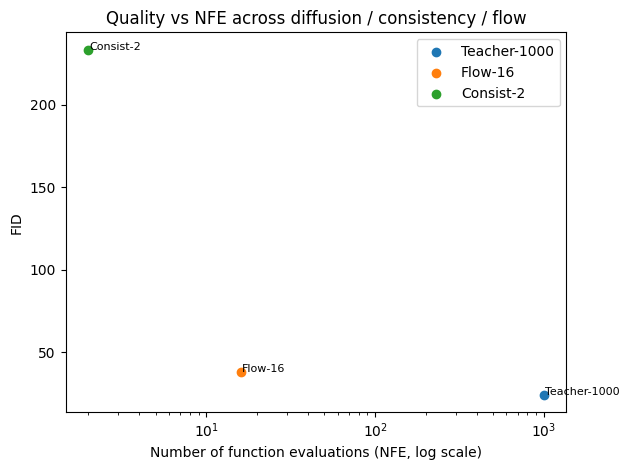

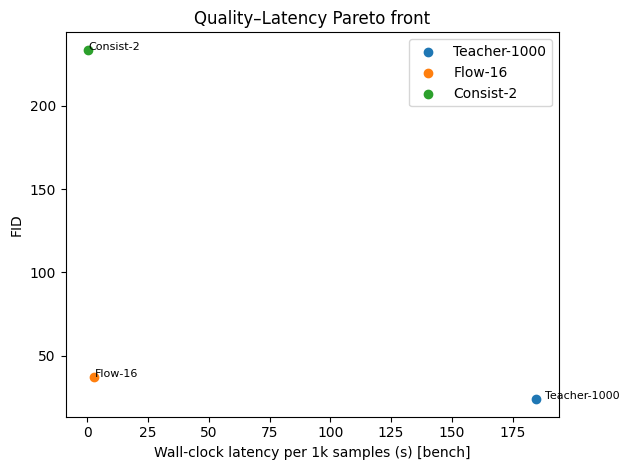

Saved figures to: /content/FastFlowDiff_CIFAR10/figures


In [ ]:
os.makedirs(FIG_DIR, exist_ok=True)

# Quality vs NFE (log-scale x-axis)
plt.figure()
for exp in experiments_latency:
    plt.scatter(exp["nfe"], exp["fid"], label=exp["name"])
    plt.text(exp["nfe"] * 1.02, exp["fid"], exp["name"], fontsize=8)
plt.xscale("log")
plt.xlabel("Number of function evaluations (NFE, log scale)")
plt.ylabel("FID")
plt.title("Quality vs NFE across diffusion / consistency / flow")
plt.legend()
plt.tight_layout()
fig_path_nfe = os.path.join(FIG_DIR, "quality_vs_nfe.png")
plt.savefig(fig_path_nfe, dpi=200)
plt.show()

# Quality–Latency Pareto (using bench time per 1k)
plt.figure()
for exp in experiments_latency:
    plt.scatter(exp["time_1k_bench"], exp["fid"], label=exp["name"])
    plt.text(exp["time_1k_bench"] * 1.02, exp["fid"], exp["name"], fontsize=8)
plt.xlabel("Wall-clock latency per 1k samples (s) [bench]")
plt.ylabel("FID")
plt.title("Quality–Latency Pareto front")
plt.legend()
plt.tight_layout()
fig_path_latency = os.path.join(FIG_DIR, "quality_latency_pareto.png")
plt.savefig(fig_path_latency, dpi=200)
plt.show()

print("Saved figures to:", FIG_DIR)


### save

In [ ]:
# Copy samples (this can be large: 3 * 50k images)
copy_item_to_drive(SAMPLES_DIR)

# Copy figures
copy_item_to_drive(FIG_DIR)

print("All main artifacts synchronized to Google Drive:", DRIVE_PROJECT_DIR)


[Drive sync] Copied /content/FastFlowDiff_CIFAR10/samples -> /content/drive/MyDrive/FastFlowDiff_CIFAR10/samples
[Drive sync] Copied /content/FastFlowDiff_CIFAR10/figures -> /content/drive/MyDrive/FastFlowDiff_CIFAR10/figures
All main artifacts synchronized to Google Drive: /content/drive/MyDrive/FastFlowDiff_CIFAR10


#